# Лабораторная работа №1 (продолжение)
## Типы признаков, природа пропусков, выбросы и статистики

**Датасет:** Titanic
**Автор:** Плеханова Арина Владимировна, группа 303

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [13]:
df = pd.read_csv("Titanic-Dataset.csv")
print("Размер:", df.shape)
df.head()

Размер: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Задание 1. Типы шкал измерения

Шкалы: номинальная (только равенство), порядковая (есть порядок),
интервальная (сложение/вычитание, нет истинного нуля),
отношений (всё + истинный ноль).

In [14]:
scales = pd.DataFrame({
    "Признак": ["PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
                "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"],
    "Шкала": ["Номинальная (ID)", "Номинальная (бинарная)", "Порядковая",
              "Номинальная (текст)", "Номинальная", "Отношений",
              "Отношений (дискретная)", "Отношений (дискретная)",
              "Номинальная (ID)", "Отношений", "Номинальная", "Номинальная"],
    "Среднее?": ["Нет", "Нет (доля — да)", "Нет", "Нет", "Нет",
                 "Да", "Условно", "Условно", "Нет", "Да", "Нет", "Нет"],
    "Медиана?": ["Нет", "Условно", "Да", "Нет", "Нет", "Да",
                 "Да", "Да", "Нет", "Да", "Нет", "Нет"],
    "Мода?": ["Нет (все уникальны)", "Да", "Да", "Бессмысленно",
              "Да", "Да", "Да", "Да", "Да", "Да", "Да", "Да"]
})
scales

,Признак,Шкала,Среднее?,Медиана?,Мода?
0,PassengerId,Номинальная (ID),Нет,Нет,Нет (все уникальны)
1,Survived,Номинальная (бинарная),Нет (доля — да),Условно,Да
2,Pclass,Порядковая,Нет,Да,Да
3,Name,Номинальная (текст),Нет,Нет,Бессмысленно
4,Sex,Номинальная,Нет,Нет,Да
5,Age,Отношений,Да,Да,Да
6,SibSp,Отношений (дискретная),Условно,Да,Да
7,Parch,Отношений (дискретная),Условно,Да,Да
8,Ticket,Номинальная (ID),Нет,Нет,Да
9,Fare,Отношений,Да,Да,Да


**Разбор двух признаков с разными шкалами:**

**Age (шкала отношений):**
- Среднее —  корректно (29.7 лет — осмысленно).
- Медиана —  корректна.
- Мода —  считается, но бесполезна (слишком много разных значений).

**Pclass (порядковая шкала):**
- Среднее —  математически некорректно: нет равных интервалов между классами.
  pandas посчитает 2.3, но это бессмыслица.
- Медиана —  корректна: медиана = 3 говорит, что половина ехала в 3-м классе.
- Мода —  корректна и осмысленна.

**Методологически неверное:** `df["Pclass"].mean()` и `df["Survived"].mean()` —
pandas посчитает, но среднее по порядковой и номинальной шкале не имеет смысла.
Для Survived среднее ещё имеет смысл как доля выживших (0.38 = 38%),
но это уже не «среднее», а пропорция.

## Задание 2. Природа пропусков (MCAR / MAR / MNAR)

- **MCAR** — пропуск не зависит ни от чего.
- **MAR** — пропуск зависит от других наблюдаемых признаков.
- **MNAR** — пропуск зависит от самого пропущенного значения.

In [15]:
# Создаём индикатор пропуска для Age
df["Age_missing"] = df["Age"].isnull().astype(int)

print("Доля пропусков Age по классу:")
print(df.groupby("Pclass")["Age_missing"].mean().round(3))

print("\nДоля пропусков Age по полу:")
print(df.groupby("Sex")["Age_missing"].mean().round(3))

print("\nДоля пропусков Age по порту посадки:")
print(df.groupby("Embarked")["Age_missing"].mean().round(3))

Доля пропусков Age по классу:
Pclass
1    0.139
2    0.060
3    0.277
Name: Age_missing, dtype: float64

Доля пропусков Age по полу:
Sex
female    0.169
male      0.215
Name: Age_missing, dtype: float64

Доля пропусков Age по порту посадки:
Embarked
C    0.226
Q    0.636
S    0.140
Name: Age_missing, dtype: float64


**Признак с пропусками:** Age (177 пропусков, 19.9%).

**Гипотеза 1: MCAR (пропуски полностью случайны).**
Проверка: если MCAR — доля пропусков одинакова во всех группах.
Факт: по классу разброс 6% – 27.7%, по порту 14% – 63.6%.
Различия огромные → MCAR маловероятна, опровергнута.

**Гипотеза 2: MAR (пропуск зависит от других признаков).**
Проверка: сравнить доли пропусков по наблюдаемым признакам (Pclass, Sex, Embarked).
Факт:
- В 3-м классе пропусков 27.7%, во 2-м — 6.0% (разница в 4.5 раза).
- В порту Q — 63.6%, в порту S — 14.0% (разница в 4.5 раза).
→ MAR подтверждается: пропуск Age сильно зависит от Pclass и Embarked.
Возможное объяснение: пассажиры 3-го класса из Queenstown —
вероятно, эмигранты без полных документов.

**Гипотеза 3: MNAR (пропуск зависит от самого значения возраста).**
Проверить напрямую нельзя — самого значения нет.
Косвенно можно: сравнить пропуски с типом обращения в Name
(Mr/Mrs/Miss/Master) — если у какой-то категории пропусков больше,
это сигнал, что возраст скрывали по социальным причинам.

**Итог:** пропуски Age — вероятнее всего MAR.
При импутации корректно использовать группировку по Pclass и Embarked.

## Задание 3. Индикатор пропуска как источник информации

In [16]:
print("Доля выживших среди тех, у кого Age пропущен:")
print(df.groupby("Age_missing")["Survived"].mean().round(3))

print("\nТо же по Cabin (наличие каюты):")
df["Cabin_missing"] = df["Cabin"].isnull().astype(int)
print(df.groupby("Cabin_missing")["Survived"].mean().round(3))

Доля выживших среди тех, у кого Age пропущен:
Age_missing
0    0.406
1    0.294
Name: Survived, dtype: float64

То же по Cabin (наличие каюты):
Cabin_missing
0    0.667
1    0.300
Name: Survived, dtype: float64


**1. Когда факт пропуска несёт информацию:**
Когда отсутствие значения связано с целевой переменной.
Если у пассажиров без Cabin выживаемость отличается от остальных —
индикатор полезен.

**2. Почему значимость индикатора — сигнал о плохой импутации:**
Если после заполнения пропусков индикатор всё ещё «работает» в модели —
значит, заполнение размыло реальную информацию. Модель видит, что
строки с заполненными значениями ведут себя иначе, чем с исходными.

**3. Примеры:**
- **Полезен:** Cabin — наличие каюты чётко связано с выживаемостью.
- **Бесполезен:** Age — пропуски возраста слабо связаны с целевой.
- **Опасен:** доход в соцопросе — пропуск напрямую связан со значением (MNAR).
  Индикатор превратится в прокси дохода и внесёт смещение.

## Задание 4. Выброс — это ошибка или сигнал?

In [17]:
max_fare_row = df.loc[df["Fare"].idxmax()]
print("Пассажир с максимальной стоимостью билета:")
print(max_fare_row[["PassengerId", "Pclass", "Fare", "Sex", "Age", "Survived"]])

Пассажир с максимальной стоимостью билета:
PassengerId         259
Pclass                1
Fare           512.3292
Sex              female
Age                35.0
Survived              1
Name: 258, dtype: object


**Выброс:** Fare = 512.33 у пассажира 1-го класса.

**1. Реальные причины:**
- Очень богатый пассажир, купивший самый дорогой билет.
- Групповой билет — цена за каюту для нескольких человек.
- Ошибка ввода: лишняя цифра (5.12 → 512).

**2. Что хуже:**
- **Удалить** — плохо: потеряем информацию о реальной структуре (богатые пассажиры существуют).
- **Оставить без изменений** — тоже не идеально: среднее Fare завышено (32 вместо ~20), линейные модели искажены.
- **Преобразование** —  лучшее: сохраняем данные, но уменьшаем влияние.

## Задание 5. Преобразование или винизоризация?

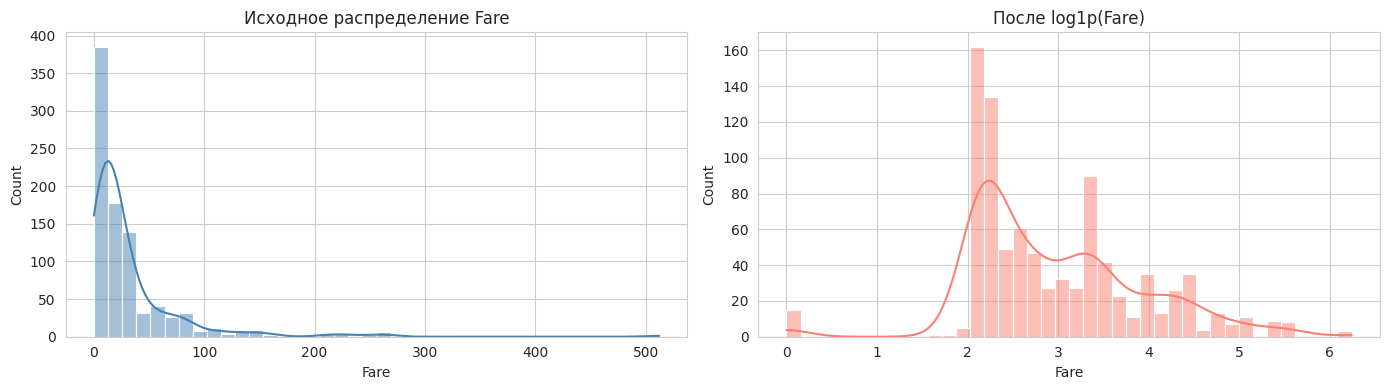

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Fare"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Исходное распределение Fare")

sns.histplot(np.log1p(df["Fare"]), bins=40, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("После log1p(Fare)")

plt.tight_layout()
plt.show()

**Когда что применять для Fare:**

- **Логарифмирование** — данные положительные и мультипликативные (доходы, цены).
  Сжимает длинный хвост, распределение становится симметричнее.
  Интерпретация: «+1 в log(Fare)» — не то же, что «+1 рубль».
  Для линейных моделей — хорошо.

- **Корень (sqrt)** — слабее логарифма, для умеренной асимметрии.
  Сохраняет ноль, интерпретация проще.

- **Винизоризация** — обрезает крайние значения до 1% и 99% перцентилей.
  Форма сохраняется, но хвосты «прижаты».
  Плохо, если выбросы — реальные сигналы (богатые пассажиры).

**Вывод:** для Fare лучше логарифмирование (выбросы реальны, форма сильно скошена).

## Задание 6. Средние, которые вводят в заблуждение

In [19]:
fare_clean = df["Fare"][df["Fare"] > 0]  # для геометрического нужны положительные

arithmetic = fare_clean.mean()
median_val = fare_clean.median()
geometric = np.exp(np.log(fare_clean).mean())

print(f"Арифметическое среднее: {arithmetic:.2f}")
print(f"Медиана:                {median_val:.2f}")
print(f"Геометрическое среднее: {geometric:.2f}")

Арифметическое среднее: 32.76
Медиана:                14.50
Геометрическое среднее: 18.98


**Почему различаются:**
При правосторонней асимметрии (много дешёвых + несколько дорогих)
арифметическое «тянется» выбросами. Медиана устойчива.
Геометрическое занимает промежуточное положение и лучше работает с
мультипликативными величинами (цены, доходы).

**Что лучше отражает «типичное»:** медиана. Половина пассажиров платила
меньше медианы, половина — больше. Арифметическое завышено из-за
нескольких дорогих билетов.

## Задание 7. Неправильная диаграмма

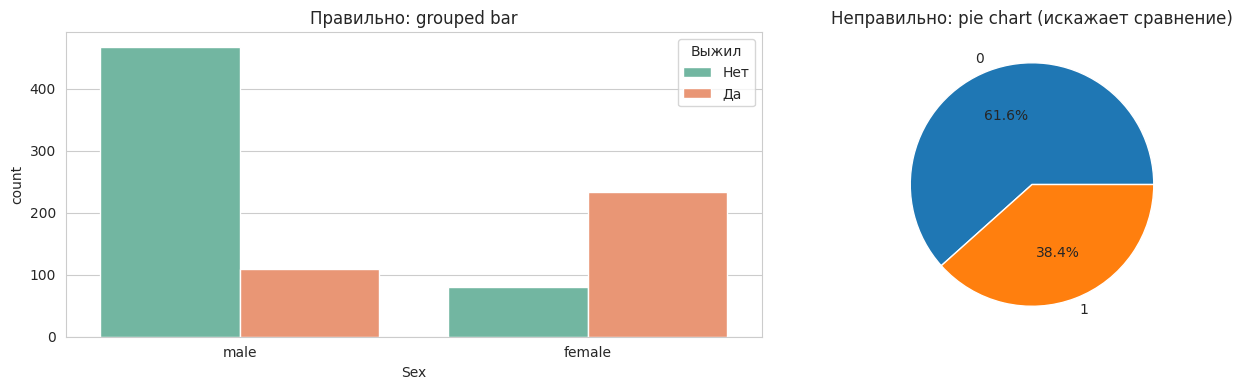

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Правильный: grouped bar
sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Правильно: grouped bar")
axes[0].legend(title="Выжил", labels=["Нет", "Да"])

# Неправильный: pie chart
sex_survived = df.groupby(["Sex", "Survived"]).size().unstack()
axes[1].pie(sex_survived.sum(), labels=sex_survived.sum().index, autopct="%1.1f%%")
axes[1].set_title("Неправильно: pie chart (искажает сравнение)")

plt.tight_layout()
plt.show()

**Правильный выбор:** grouped bar chart честно показывает и абсолютные числа,
и разницу между группами.

**Хуже был бы:** круговая диаграмма (pie chart).
- Плохо сравнивает близкие значения — глаз не различает сектор 48% и 52%.
- Не работает для 3+ категорий.
- Не показывает абсолютные числа, только доли.

**Неверный вывод зрителя:** «мужчин и женщин примерно поровну» —
хотя на самом деле мужчин почти вдвое больше (577 vs 314).

## Задание 8. Одна и та же информация — разные графики

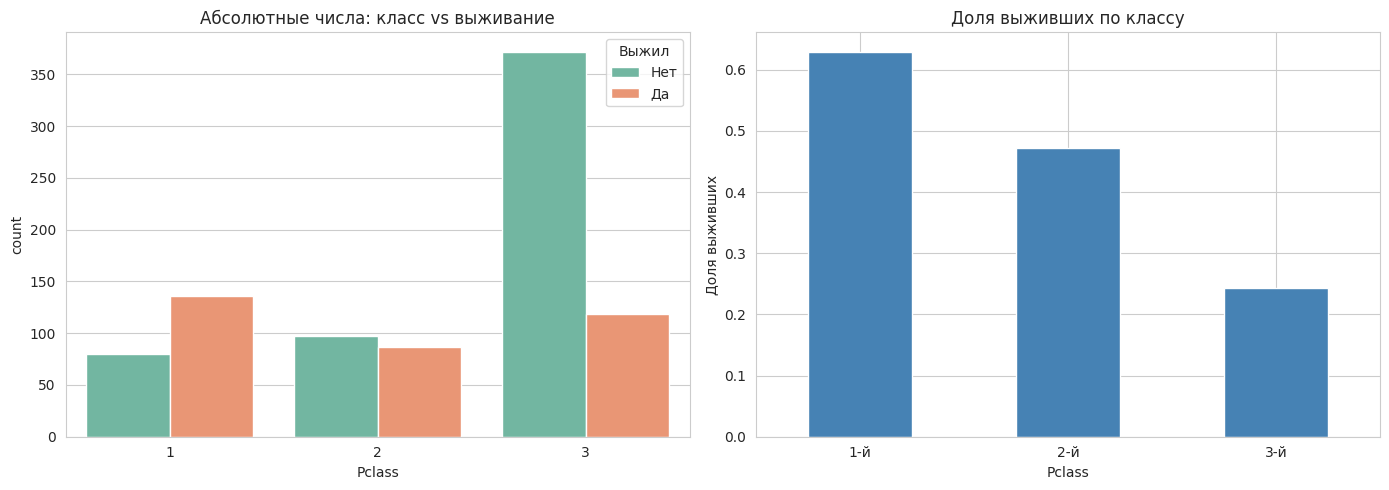

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: абсолютные числа
sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Абсолютные числа: класс vs выживание")
axes[0].legend(title="Выжил", labels=["Нет", "Да"])

# График 2: доли
survival_rate = df.groupby("Pclass")["Survived"].mean()
survival_rate.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Доля выживших по классу")
axes[1].set_ylabel("Доля выживших")
axes[1].set_xticklabels(["1-й", "2-й", "3-й"], rotation=0)

plt.tight_layout()
plt.show()

**Пара признаков:** Pclass и Survived.

**График 1 — countplot (абсолютные числа):**
Подчёркивает размер групп. Видно, что в 3-м классе больше всего жертв —
но это следствие того, что там просто больше людей.

**График 2 — доли:**
Подчёркивает пропорции. Видно закономерность: чем выше класс, тем
больше доля выживших (1-й: ~63%, 2-й: ~47%, 3-й: ~24%).

**Что легче заметить:**
- На countplot: «в 3-м классе много погибших» — но это размер группы.
- На долях: «класс влияет на выживаемость» — настоящая закономерность.

**Вывод:** показывать нужно оба графика — один про масштаб, другой про вероятность.